# Music GPT EDA + Validation Notebook

This notebook provides:
- Model checkpoint introspection (`best.pt` / `last.pt`)
- Parameter and architecture EDA
- Tokenized dataset EDA
- Validation loss testing for saved checkpoints

> Update paths in the config cell if needed.

In [1]:
from __future__ import annotations

import json
import math
import statistics
from pathlib import Path

import torch
import torch.nn.functional as F

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False
    print("matplotlib not available; plots will be skipped.")

from train_gpt import TrainConfig, MusicGPT, split_data

In [2]:
# --- Paths / knobs ---
PROJECT_ROOT = Path("..").resolve()  # notebook is in src/
DATASET_PATH = PROJECT_ROOT / "tokenized" / "dataset.jsonl"
STATS_PATH = PROJECT_ROOT / "tokenized" / "stats.json"
BEST_CKPT = PROJECT_ROOT / "src" / "best.pt"
LAST_CKPT = PROJECT_ROOT / "src" / "last.pt"

SEED = 42
VAL_RATIO = 0.03
EVAL_BATCHES = 25

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATASET_PATH)
print("Best ckpt exists:", BEST_CKPT.exists())
print("Last ckpt exists:", LAST_CKPT.exists())

Project root: C:\Users\eydos\Desktop\project x\Music_Generation
Dataset path: C:\Users\eydos\Desktop\project x\Music_Generation\tokenized\dataset.jsonl
Best ckpt exists: True
Last ckpt exists: True


In [3]:
def load_dataset_ids(path: Path) -> list[list[int]]:
    sequences: list[list[int]] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            ids = row.get("token_ids")
            if isinstance(ids, list) and len(ids) >= 2:
                sequences.append([int(x) for x in ids])
    if not sequences:
        raise RuntimeError(f"No usable sequences in {path}")
    return sequences


def summarize_lengths(lengths: list[int]) -> dict[str, float]:
    s = sorted(lengths)
    n = len(s)
    def q(p: float) -> float:
        idx = int(p * (n - 1))
        return float(s[idx])

    return {
        "count": float(n),
        "min": float(s[0]),
        "p25": q(0.25),
        "median": q(0.5),
        "p75": q(0.75),
        "p90": q(0.9),
        "p95": q(0.95),
        "max": float(s[-1]),
        "mean": float(statistics.mean(s)),
    }


def sample_batch_ids(
    sequences: list[list[int]],
    batch_size: int,
    seq_len: int,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    valid = [s for s in sequences if len(s) > seq_len]
    if not valid:
        raise RuntimeError(f"No sequences long enough for seq_len={seq_len}")

    x_list, y_list = [], []
    for _ in range(batch_size):
        seq = valid[torch.randint(0, len(valid), (1,)).item()]
        start = torch.randint(0, len(seq) - seq_len, (1,)).item()
        chunk = seq[start : start + seq_len + 1]
        x_list.append(torch.tensor(chunk[:-1], dtype=torch.long))
        y_list.append(torch.tensor(chunk[1:], dtype=torch.long))

    x = torch.stack(x_list, dim=0).to(device)
    y = torch.stack(y_list, dim=0).to(device)
    return x, y


@torch.no_grad()
def eval_checkpoint(
    ckpt_path: Path,
    val_sequences: list[list[int]],
    eval_batches: int,
    device: torch.device,
) -> dict:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    cfg = TrainConfig(**ckpt["config"])

    model = MusicGPT(cfg)
    model.load_state_dict(ckpt["model_state"])
    model.to(device)
    model.eval()

    use_amp = device.type == "cuda"
    losses = []
    for _ in range(eval_batches):
        x, y = sample_batch_ids(val_sequences, cfg.batch_size, cfg.max_seq_len, device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
        losses.append(float(loss.item()))

    mean_loss = sum(losses) / len(losses)
    ppl = math.exp(mean_loss)

    return {
        "path": str(ckpt_path),
        "step": ckpt.get("step", -1),
        "mean_val_loss": mean_loss,
        "perplexity": ppl,
        "eval_batches": eval_batches,
        "cfg": cfg,
        "raw_losses": losses,
    }

## Dataset EDA

In [4]:
stats = {}
if STATS_PATH.exists():
    stats = json.loads(STATS_PATH.read_text(encoding="utf-8"))
    print("stats.json:")
    for k, v in stats.items():
        print(f"- {k}: {v}")
else:
    print("stats.json not found")

sequences = load_dataset_ids(DATASET_PATH)
lengths = [len(s) for s in sequences]
length_summary = summarize_lengths(lengths)

print("\nLength summary from dataset.jsonl:")
for k, v in length_summary.items():
    print(f"- {k}: {v:.2f}")

stats.json:
- input_dir: data_processed
- output_dir: tokenized
- time_step_seconds: 0.125
- max_time_shift: 100
- min_tokens: 1
- total_files_seen: 26784
- tokenized_files: 26784
- skipped_files: 0
- verification_sample_requested: 0
- verification_sample_checked: 0
- verification_failures: 0
- vocabulary_size: 288
- average_sequence_length: 691.5238575268817
- min_sequence_length: 29
- max_sequence_length: 1929

Length summary from dataset.jsonl:
- count: 26784.00
- min: 29.00
- p25: 512.00
- median: 693.00
- p75: 863.00
- p90: 1014.00
- p95: 1117.00
- max: 1929.00
- mean: 691.52


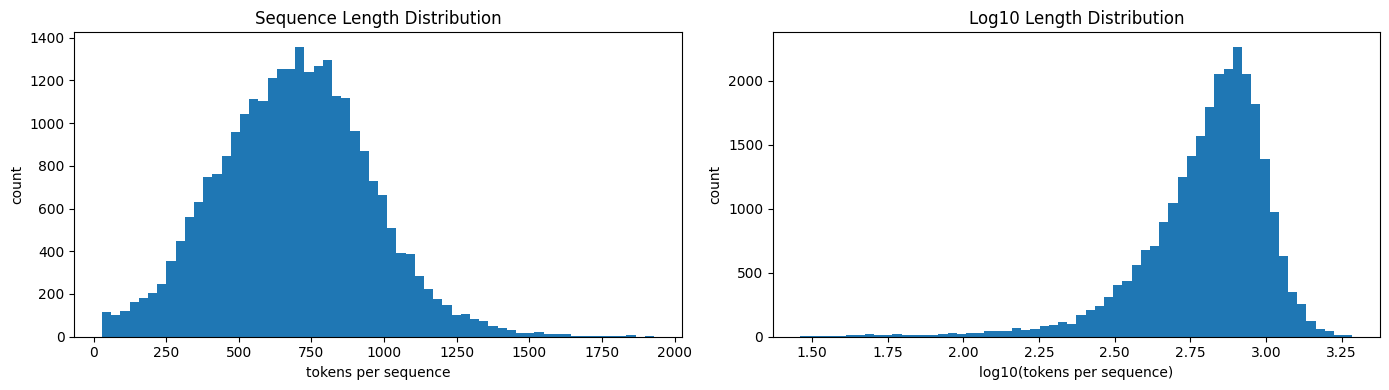

In [5]:
if HAS_MPL:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    ax[0].hist(lengths, bins=60)
    ax[0].set_title("Sequence Length Distribution")
    ax[0].set_xlabel("tokens per sequence")
    ax[0].set_ylabel("count")

    ax[1].hist([math.log10(max(1, x)) for x in lengths], bins=60)
    ax[1].set_title("Log10 Length Distribution")
    ax[1].set_xlabel("log10(tokens per sequence)")
    ax[1].set_ylabel("count")

    plt.tight_layout()
    plt.show()
else:
    print("Install matplotlib to see plots.")

## Model EDA

In [6]:
def count_parameters(model: torch.nn.Module) -> tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def per_module_param_counts(model: torch.nn.Module) -> list[tuple[str, int]]:
    rows = []
    for name, module in model.named_children():
        cnt = sum(p.numel() for p in module.parameters())
        rows.append((name, cnt))
    return rows

In [7]:
# Load one checkpoint for architecture introspection (prefer best)
arch_ckpt = BEST_CKPT if BEST_CKPT.exists() else LAST_CKPT
if not arch_ckpt.exists():
    raise FileNotFoundError("Neither best.pt nor last.pt found under src/")

arch_obj = torch.load(arch_ckpt, map_location="cpu")
arch_cfg = TrainConfig(**arch_obj["config"])
arch_model = MusicGPT(arch_cfg)
arch_model.load_state_dict(arch_obj["model_state"])

total_params, trainable_params = count_parameters(arch_model)
print(f"Checkpoint used: {arch_ckpt.name}")
print(f"Saved at step: {arch_obj.get('step', -1)}")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Approx model size (fp32): {total_params * 4 / (1024**2):.2f} MB")
print("\nConfig:")
for k, v in arch_obj["config"].items():
    print(f"- {k}: {v}")

print("\nTop-level module param counts:")
for name, cnt in per_module_param_counts(arch_model):
    print(f"- {name}: {cnt:,}")

Checkpoint used: best.pt
Saved at step: 6000
Total params: 11,065,344
Trainable params: 11,065,344
Approx model size (fp32): 42.21 MB

Config:
- data_path: tokenized/dataset.jsonl
- out_dir: src
- seed: 42
- val_ratio: 0.03
- max_seq_len: 512
- vocab_size: 288
- d_model: 384
- n_layers: 6
- n_heads: 6
- d_ff: 1536
- dropout: 0.1
- batch_size: 12
- grad_accum_steps: 4
- max_steps: 12000
- eval_every: 200
- eval_batches: 25
- save_every: 500
- lr: 0.0006
- min_lr: 6e-05
- warmup_steps: 600
- weight_decay: 0.1
- grad_clip: 1.0
- log_every: 1
- early_stop_patience: 12
- early_stop_min_delta: 0.0001

Top-level module param counts:
- tok_emb: 110,592
- pos_emb: 196,608
- drop: 0
- blocks: 10,646,784
- ln_f: 768
- head: 110,592


## Validation Testing (`best.pt` and `last.pt`)

In [8]:
# Rebuild train/val split exactly like training code
train_sequences, val_sequences = split_data(sequences, val_ratio=VAL_RATIO, seed=SEED)
print(f"Train sequences: {len(train_sequences):,}")
print(f"Val sequences:   {len(val_sequences):,}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train sequences: 25,981
Val sequences:   803
Device: cuda


In [9]:
results = []
for ckpt_path in [BEST_CKPT, LAST_CKPT]:
    if ckpt_path.exists():
        out = eval_checkpoint(
            ckpt_path=ckpt_path,
            val_sequences=val_sequences,
            eval_batches=EVAL_BATCHES,
            device=device,
        )
        results.append(out)
    else:
        print(f"Missing checkpoint: {ckpt_path}")

if not results:
    raise RuntimeError("No checkpoints found to evaluate.")

print("Validation results:")
for r in results:
    print(
        f"- {Path(r['path']).name}: step={r['step']}, "
        f"val_loss={r['mean_val_loss']:.4f}, ppl={r['perplexity']:.2f}"
    )

Validation results:
- best.pt: step=6000, val_loss=1.4582, ppl=4.30
- last.pt: step=6000, val_loss=1.4764, ppl=4.38


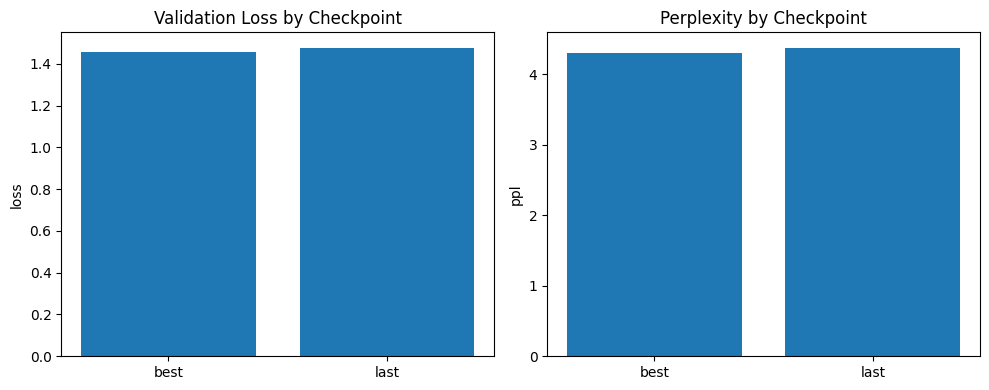

In [10]:
if HAS_MPL and results:
    names = [Path(r["path"]).stem for r in results]
    losses = [r["mean_val_loss"] for r in results]
    ppls = [r["perplexity"] for r in results]

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].bar(names, losses)
    ax[0].set_title("Validation Loss by Checkpoint")
    ax[0].set_ylabel("loss")

    ax[1].bar(names, ppls)
    ax[1].set_title("Perplexity by Checkpoint")
    ax[1].set_ylabel("ppl")

    plt.tight_layout()
    plt.show()

## How to Read Results

- Prefer the checkpoint with lower validation loss/perplexity (usually `best.pt`).
- If `last.pt` is close to `best.pt`, training likely ended near convergence.
- If both are high, train longer or tune hyperparameters.

Optional next additions:
- Add token-level accuracy on validation.
- Add per-position loss curves.
- Add generation quality checks from the same checkpoints.